In [25]:
!pip install -q ultralytics

In [26]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KRyzoZc9BF8Xf53srL4o")
project = rf.workspace("h1-la").project("diagramvision-flowchart-2evwi")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [27]:
model = YOLO("yolo11n.pt")

In [28]:
results = model.train(
    data="/content/DiagramVision-FlowChart-1/data.yaml",
    epochs=30,
    imgsz=512,
    batch=8,
    project="/content/DiagramVision",
    name="flowchart_detector"
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DiagramVision-FlowChart-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=flowchart_detector-8, nbs=64, nm

In [29]:
# evaluation

best_model = YOLO("/content/DiagramVision/flowchart_detector-7/weights/best.pt")

metrics = best_model.val(data="/content/DiagramVision-FlowChart-1/data.yaml", plots=True)

print(f"mAP@50: {metrics.box.map50:.3f}")
print(f"mAP@50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 609.2±256.9 MB/s, size: 18.6 KB)
val: Scanning /content/DiagramVision-FlowChart-1/valid/labels.cache... 10 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10/10 2.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5s/it 1.5s
                   all         10         31      0.511      0.581      0.528      0.341
             Descision         10         10      0.566        0.7      0.551      0.406
               Process          9          9       0.22      0.315      0.181     0.0993
          input_output          2          2      0.368        0.5      0.525      0.315
            start_stop         10         10       0.89       0.81      0.855      0.544
Speed: 1.1ms preprocess, 122.9ms 

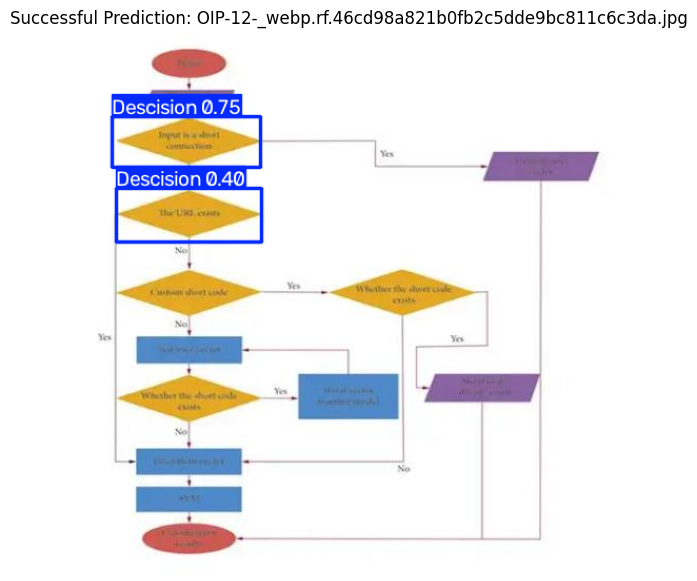

Successful Case Image: OIP-12-_webp.rf.46cd98a821b0fb2c5dde9bc811c6c3da.jpg


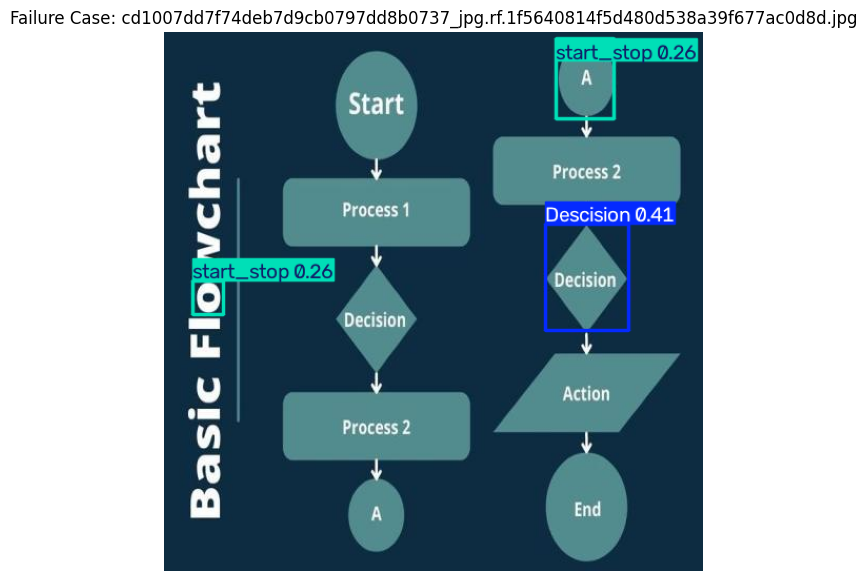

Failure Case Image: cd1007dd7f74deb7d9cb0797dd8b0737_jpg.rf.1f5640814f5d480d538a39f677ac0d8d.jpg


In [30]:
from pathlib import Path
import matplotlib.pyplot as plt

# Choose images
success_index = 1   # Test Image 2
failure_index = 3   # Test Image 4

# Successful Prediction

success_result = test_results[success_index]
success_name = Path(success_result.path).name

success_img = success_result.plot()

plt.figure(figsize=(10, 7))
plt.imshow(success_img[..., ::-1])
plt.title(f"Successful Prediction: {success_name}")
plt.axis("off")
plt.show()

print("Successful Case Image:", success_name)


# Failure Prediction

failure_result = test_results[failure_index]
failure_name = Path(failure_result.path).name

failure_img = failure_result.plot()

plt.figure(figsize=(10, 7))
plt.imshow(failure_img[..., ::-1])
plt.title(f"Failure Case: {failure_name}")
plt.axis("off")
plt.show()

print("Failure Case Image:", failure_name)

In [31]:
#op

best_model.export(format="onnx")

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 100 layers, 2,582,932 parameters, 0 gradients, 4.1 GFLOPs

PyTorch: starting from '/content/DiagramVision/flowchart_detector-7/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 8, 5376) (5.2 MB)

ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 1.8s, saved as '/content/DiagramVision/flowchart_detector-7/weights/best.onnx' (10.1 MB)

Export complete (2.4s)
Results saved to /content/DiagramVision/flowchart_detector-7/weights/best.onnx
Predict:         yolo predict task=detect model=/content/DiagramVision/flowchart_detector-7/weights/best.onnx imgsz=512 
Validate:        yolo val task=detect model=/content/DiagramVision/flowchart_detector-7/weights/best.onnx imgsz=512 data=/content/DiagramVision-FlowChart-1/data.yaml  
Visualize:       https://netron.app


'/content/DiagramVision/flowchart_detector-7/weights/best.onnx'